### Look at Heen Met Data to see what there is there...

created by Cassie Lumbrazo\
last updated: April 2026\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd

from zoneinfo import ZoneInfo
from pathlib import Path

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/heen'

## Load Heen SNOTEL Data

In [3]:
# open observations
file_heen = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/site1270_hourly_2016_2026.nc"
met_heen = xr.open_dataset(file_heen)

# cut the datetime to be from 2024 10 01 to 2025 09 30 to match the snowpack output
met_heen_WY2025 = met_heen.sel(datetime=slice("2024-10-01", "2025-09-30"))
met_heen_WY2025


<xarray.Dataset> Size: 777kB
Dimensions:   (datetime: 7772)
Coordinates:
  * datetime  (datetime) datetime64[ns] 62kB 2024-10-01 ... 2025-09-30T23:00:00
Data variables:
    site_id   (datetime) int32 31kB ...
    swe       (datetime) float64 62kB ...
    precip1   (datetime) float64 62kB ...
    precip2   (datetime) float64 62kB ...
    temp      (datetime) float64 62kB ...
    hs        (datetime) float64 62kB ...
    bat       (datetime) float64 62kB ...
    wdir      (datetime) float64 62kB ...
    ws_x      (datetime) float64 62kB ...
    ws_v      (datetime) float64 62kB ...
    rh        (datetime) float64 62kB ...
    pres      (datetime) float64 62kB ...

In [19]:
met_heen.temp

<xarray.DataArray 'temp' (datetime: 83296)> Size: 666kB
[83296 values with dtype=float64]
Coordinates:
  * datetime  (datetime) datetime64[ns] 666kB 2015-10-01 ... 2026-03-20T08:00:00

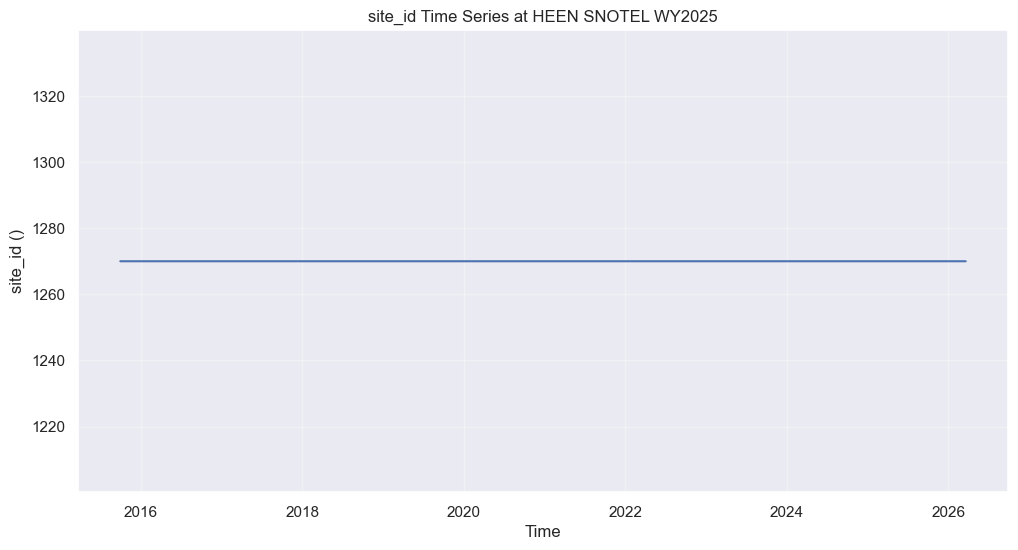

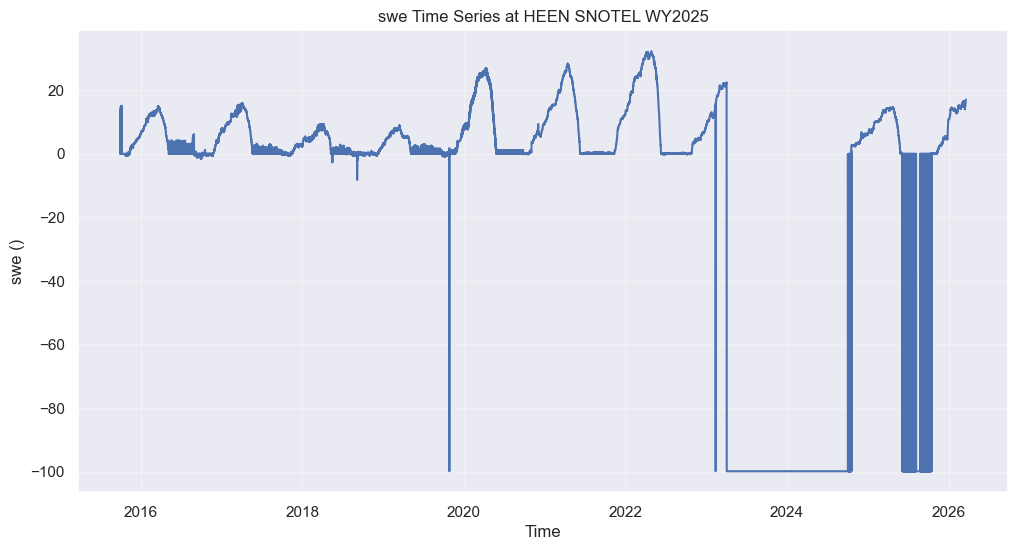

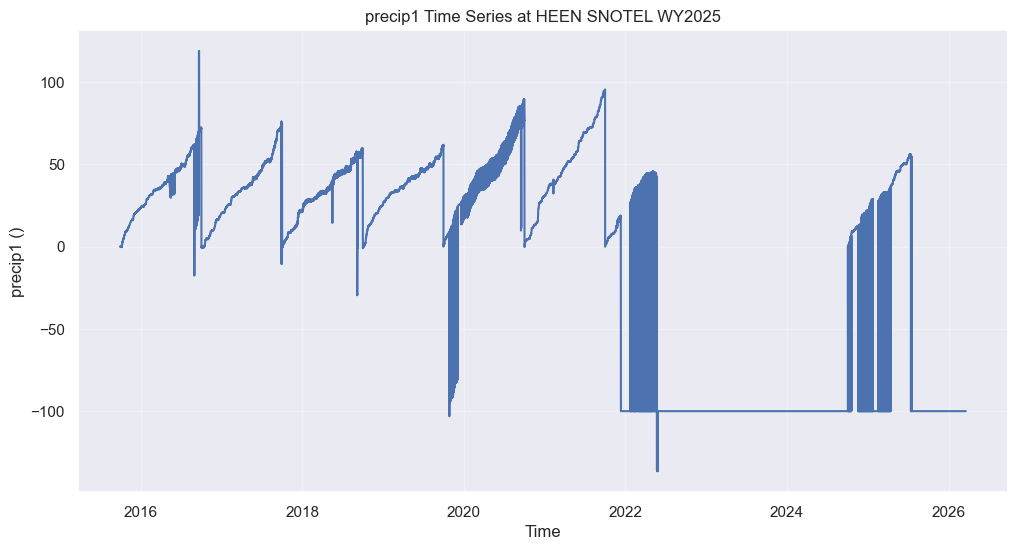

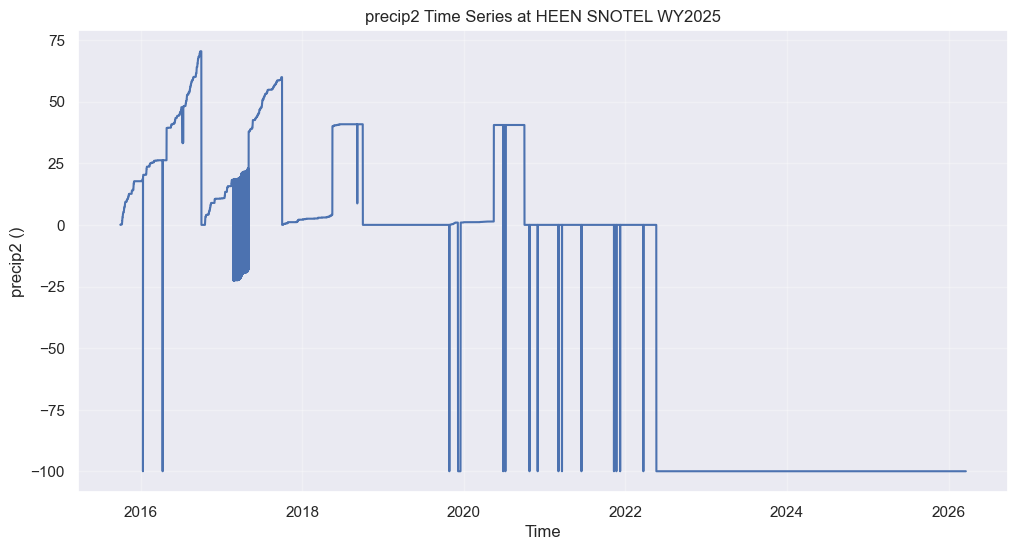

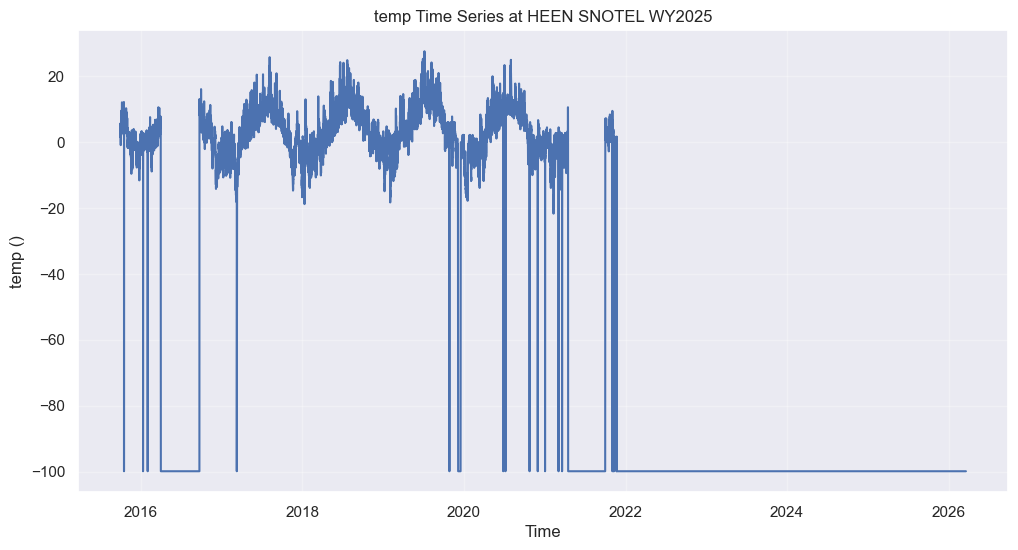

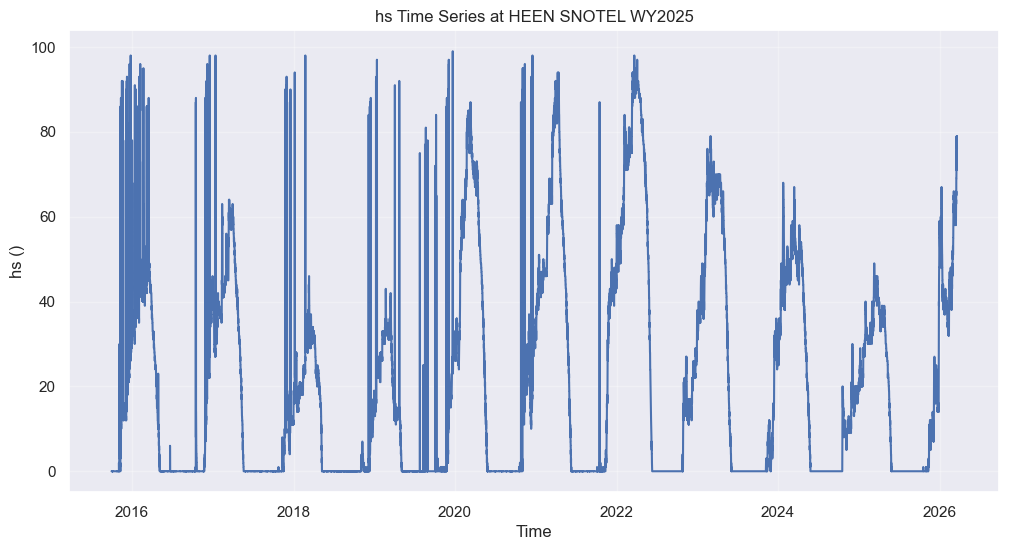

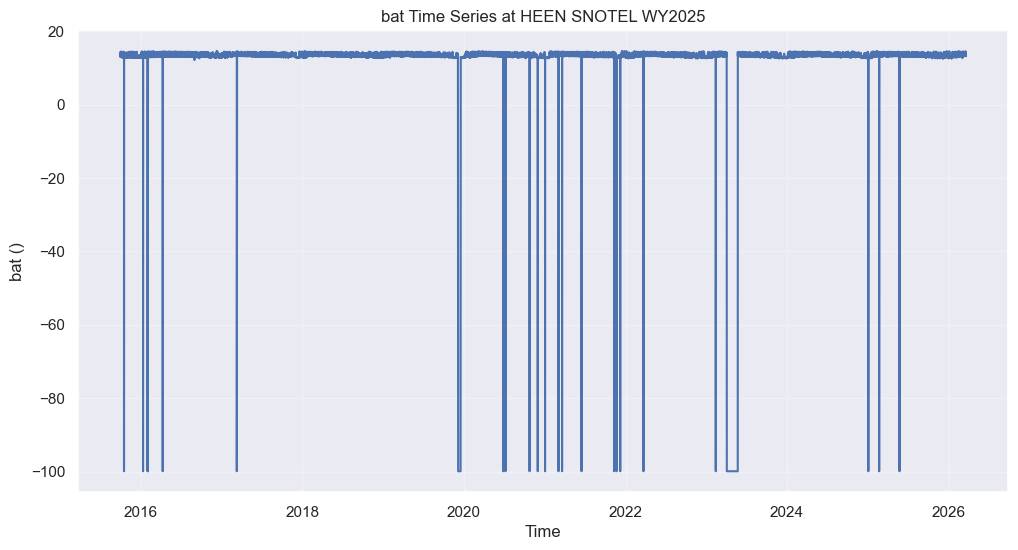

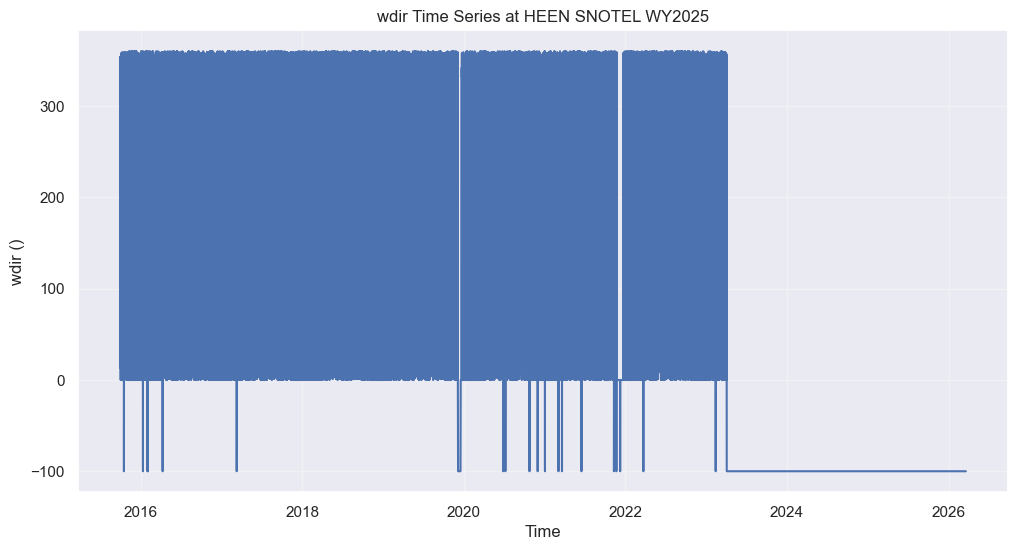

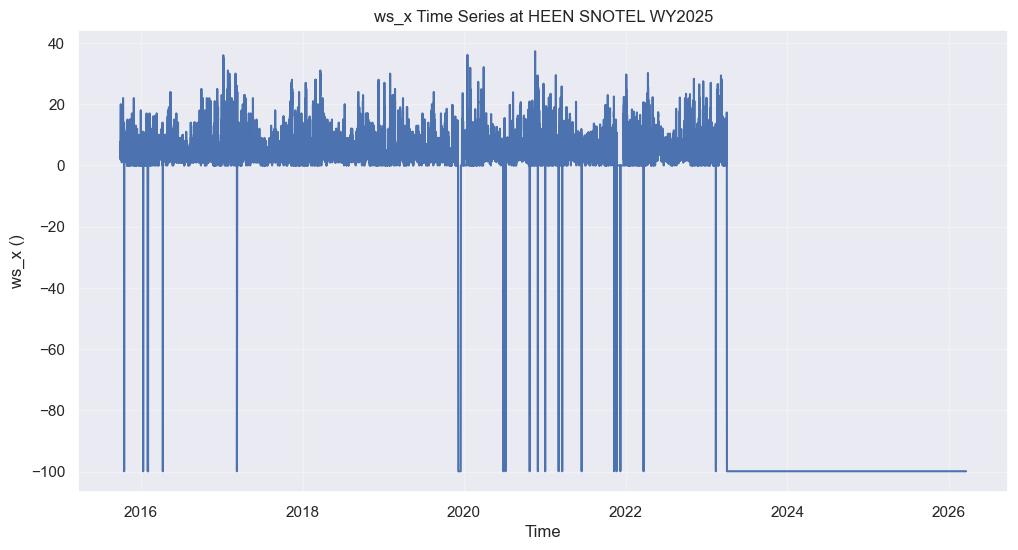

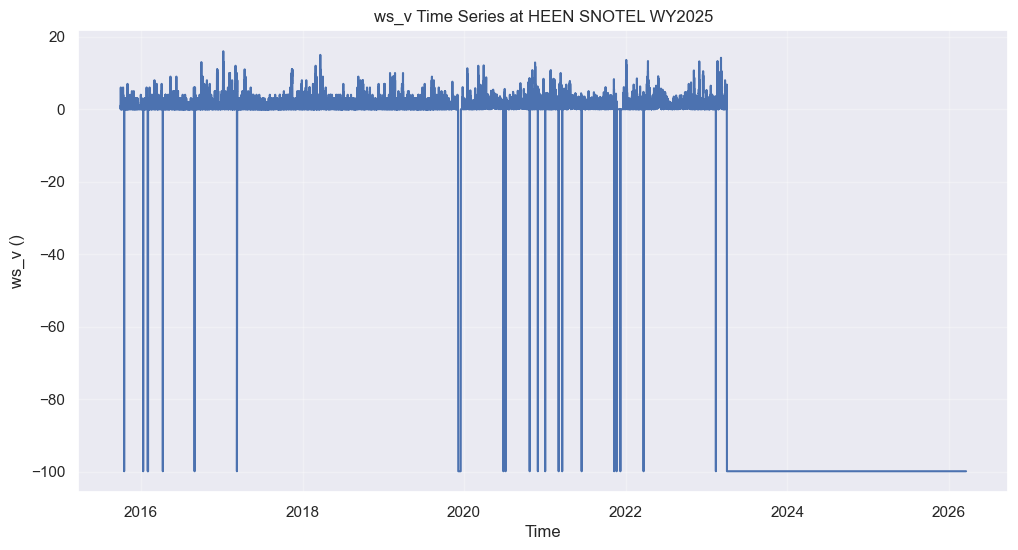

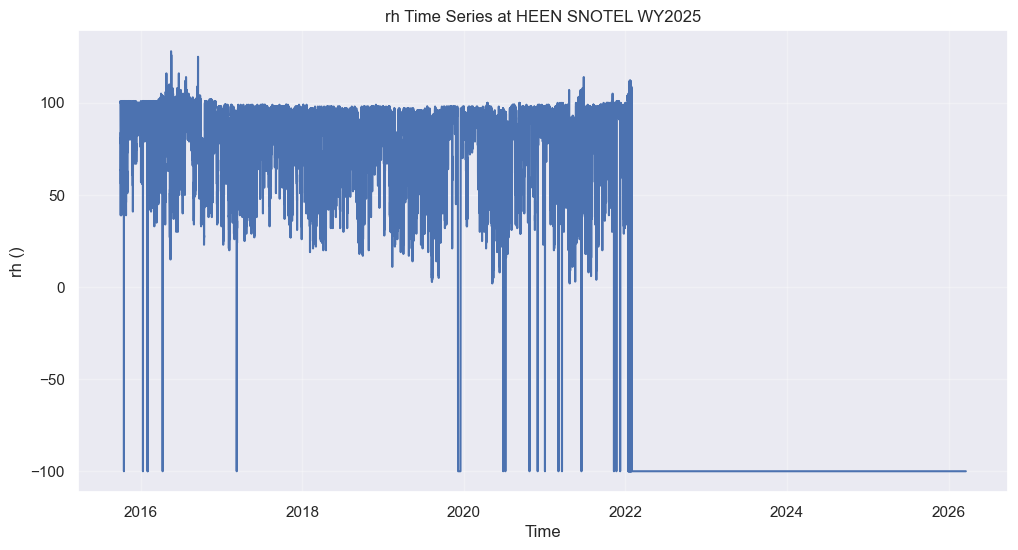

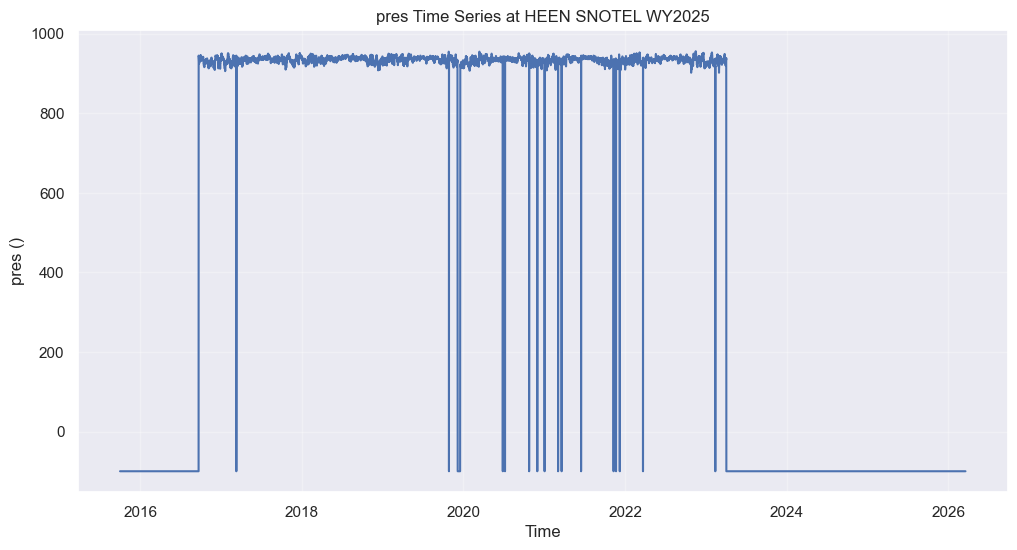

In [4]:
# plot all the variables to see what we have and how they look
for var in met_heen.data_vars:
    plt.figure()
    met_heen[var].plot()
    plt.title(f"{var} Time Series at HEEN SNOTEL WY2025")
    plt.xlabel("Time")
    plt.ylabel(f"{var} ({met_heen[var].attrs.get('units', '')})")
    plt.grid(True, alpha=0.3)
    plt.show()
    

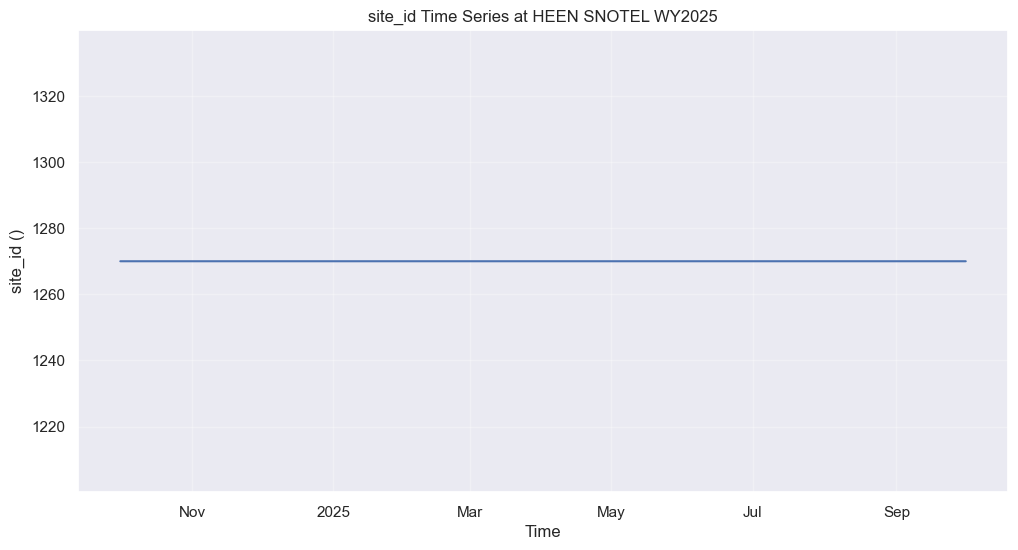

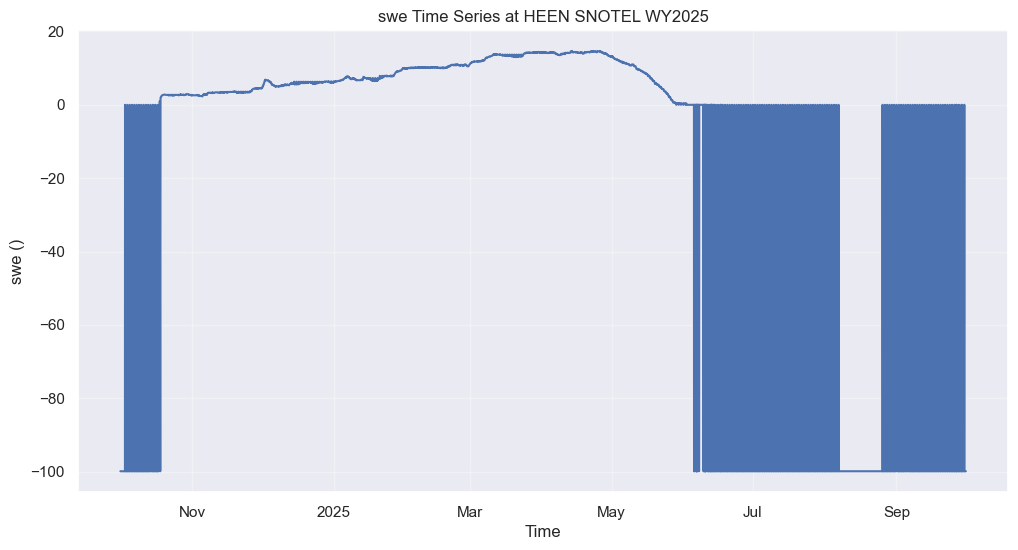

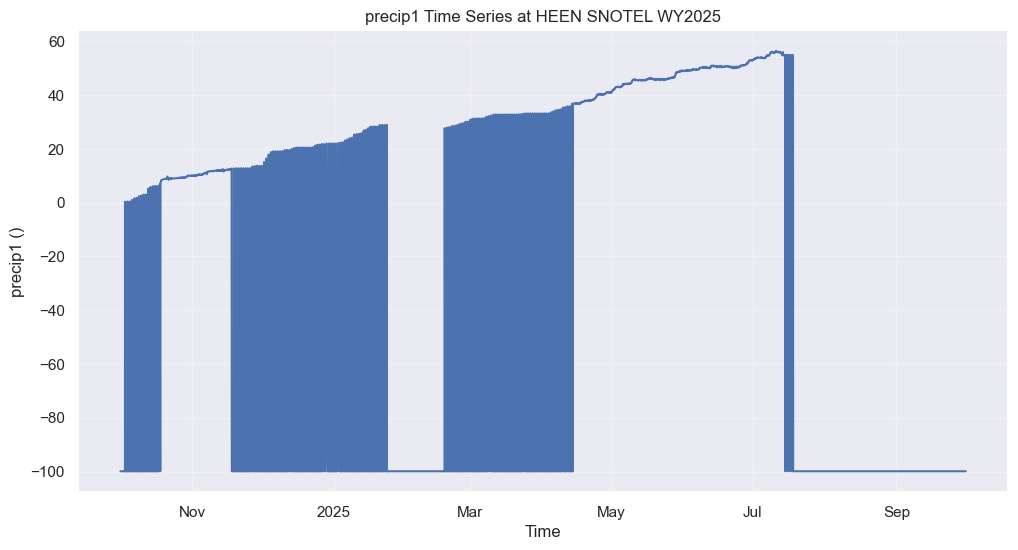

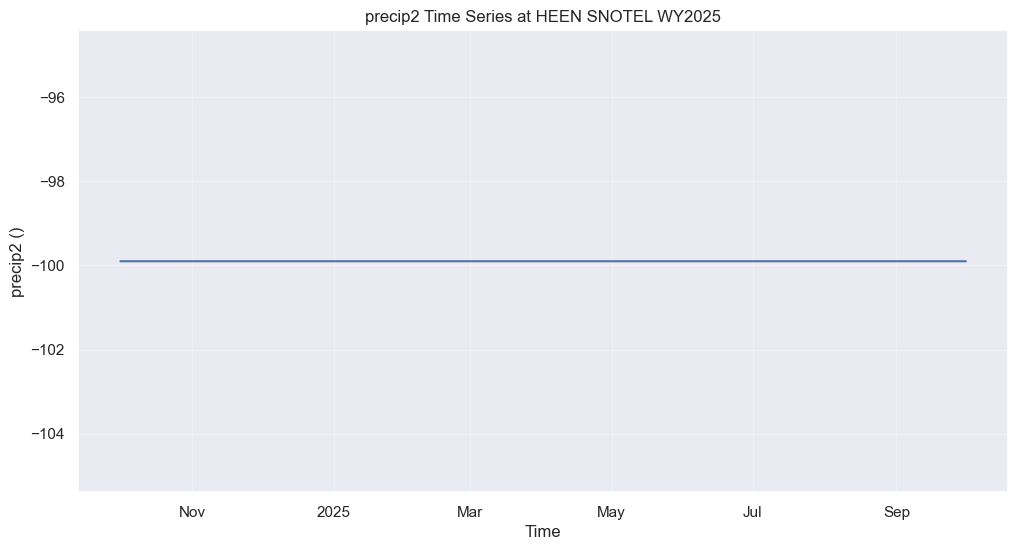

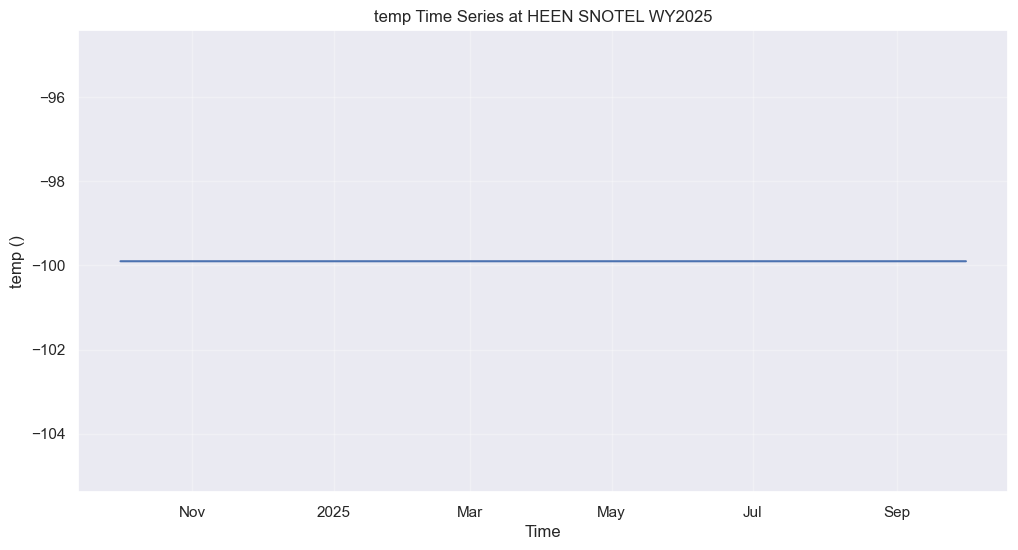

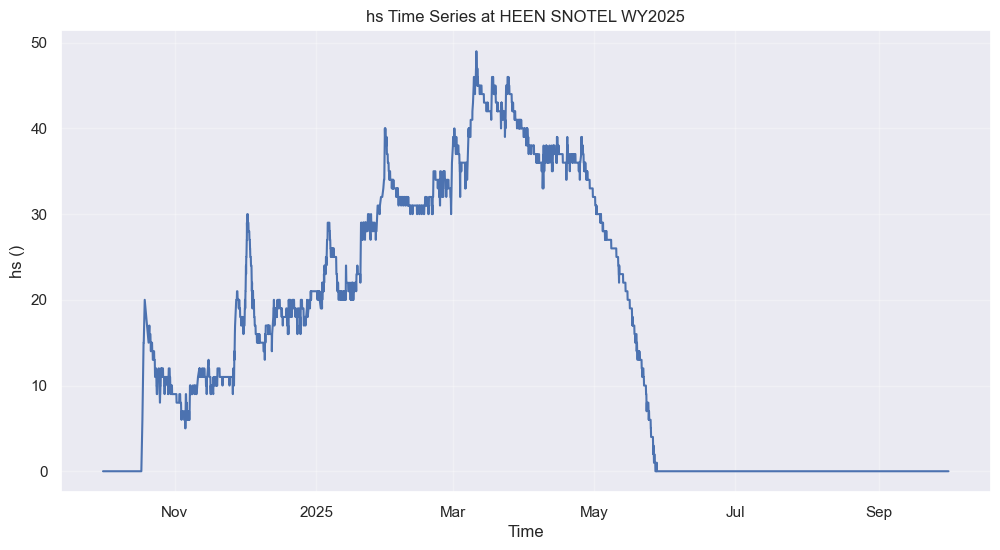

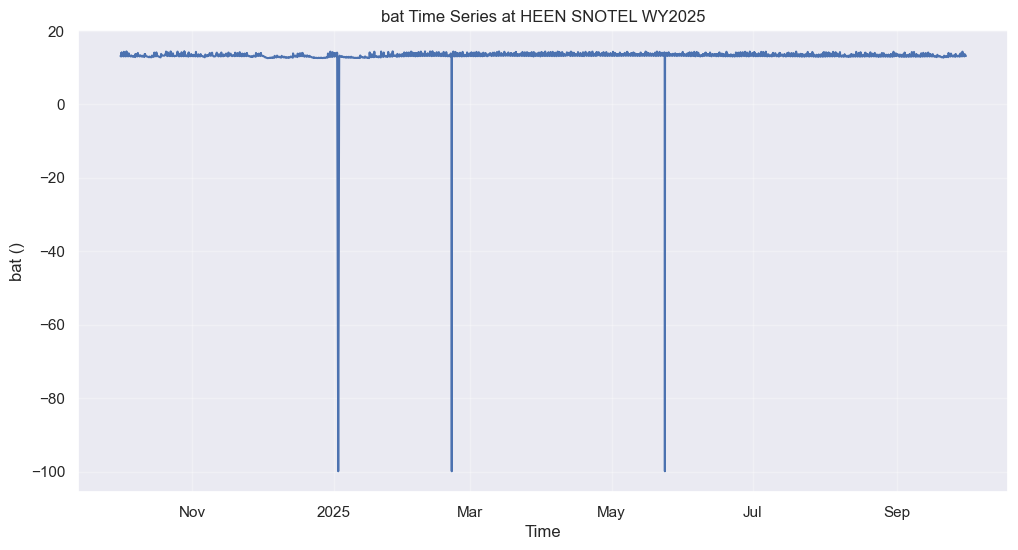

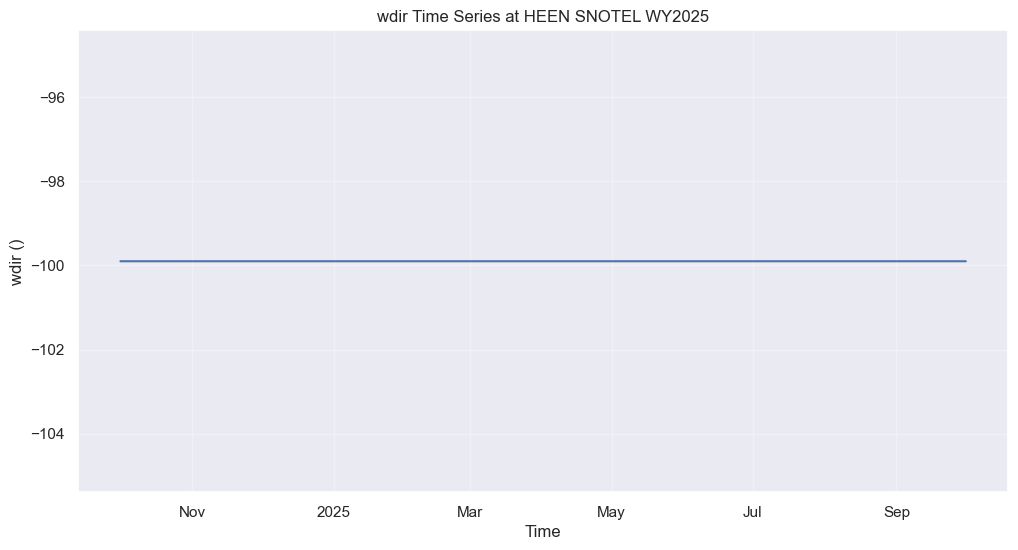

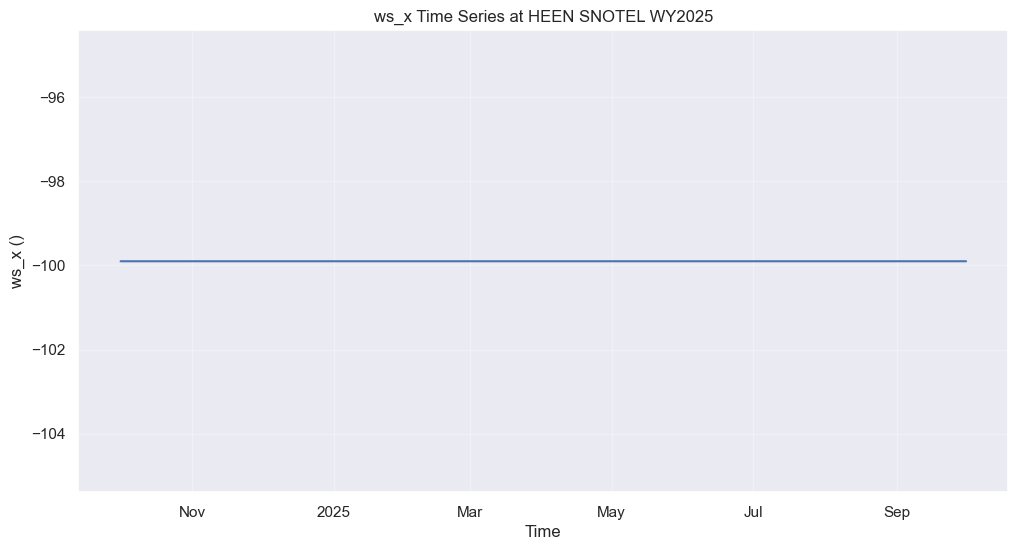

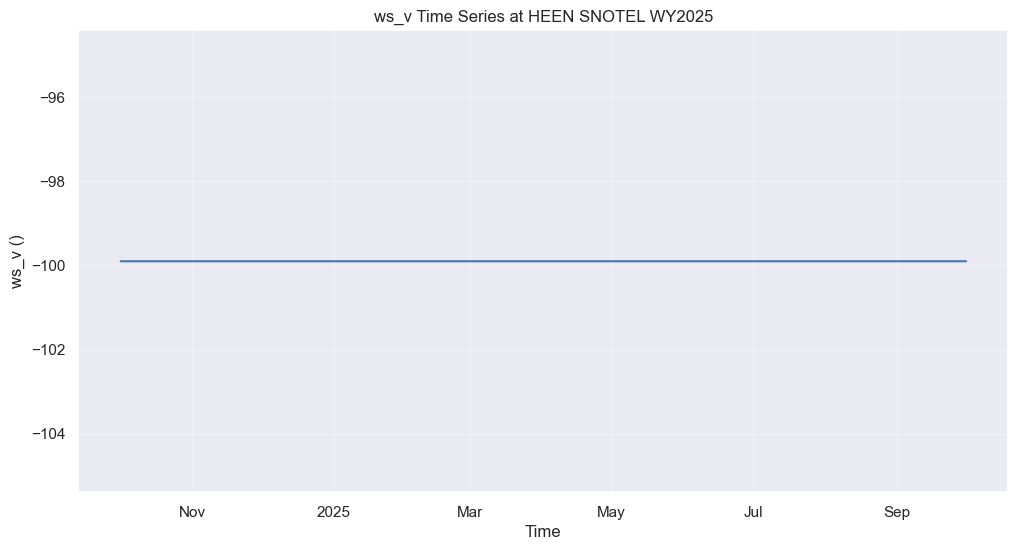

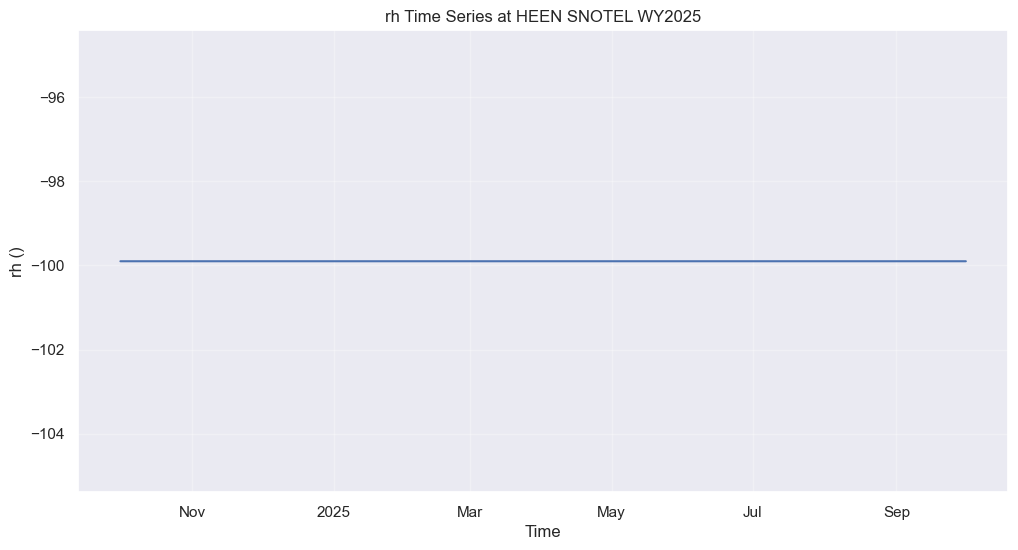

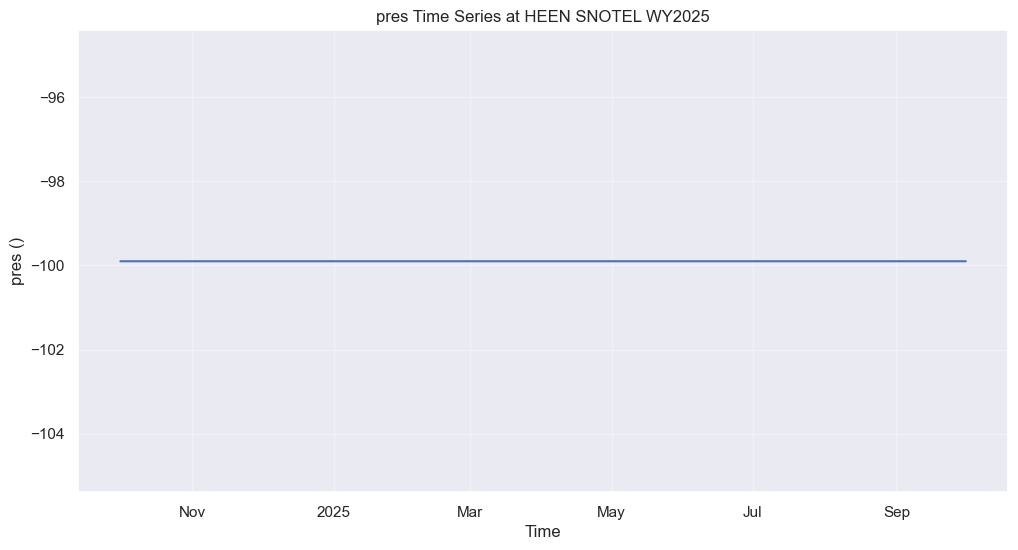

In [5]:
# plot all the variables to see what we have and how they look
for var in met_heen_WY2025.data_vars:
    plt.figure()
    met_heen_WY2025[var].plot()
    plt.title(f"{var} Time Series at HEEN SNOTEL WY2025")
    plt.xlabel("Time")
    plt.ylabel(f"{var} ({met_heen_WY2025[var].attrs.get('units', '')})")
    plt.grid(True, alpha=0.3)
    plt.show()
    

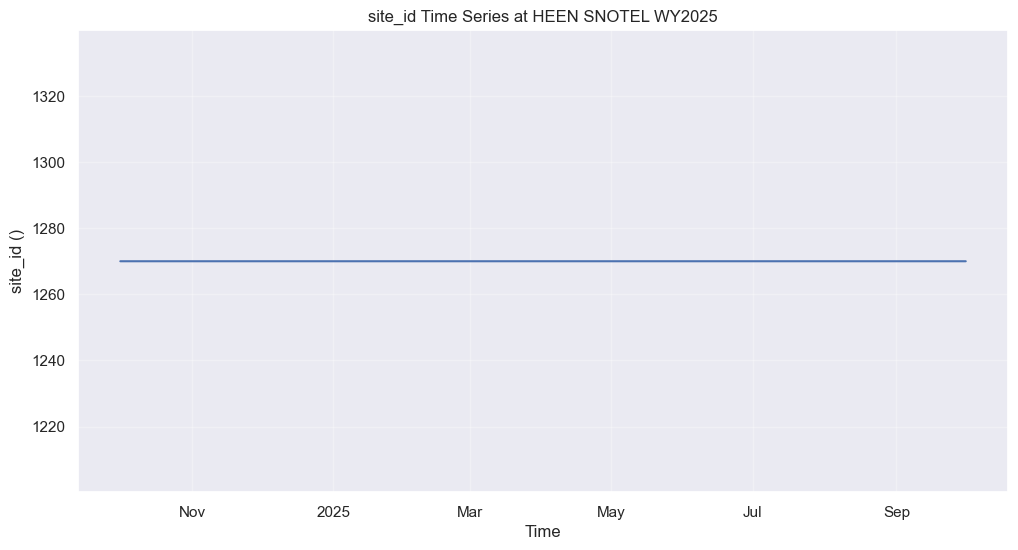

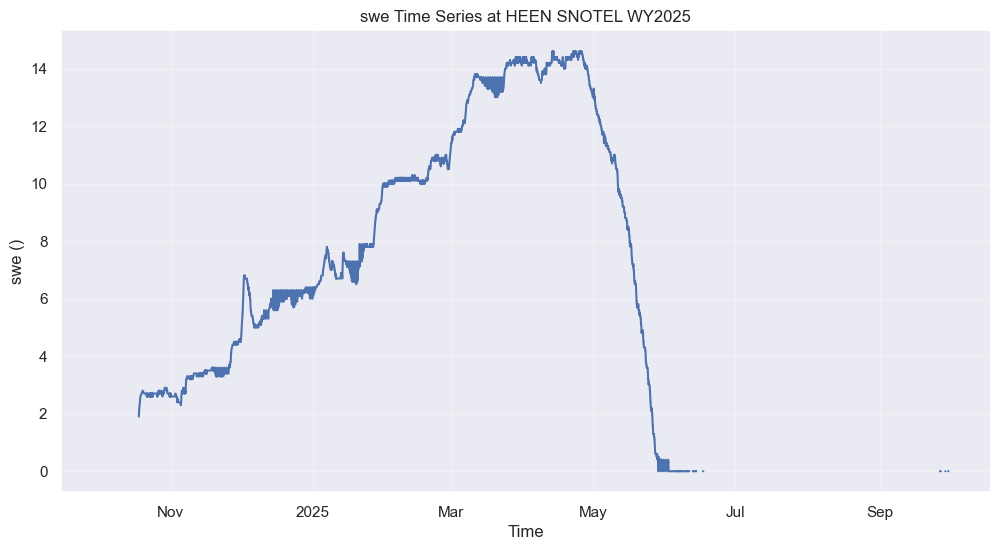

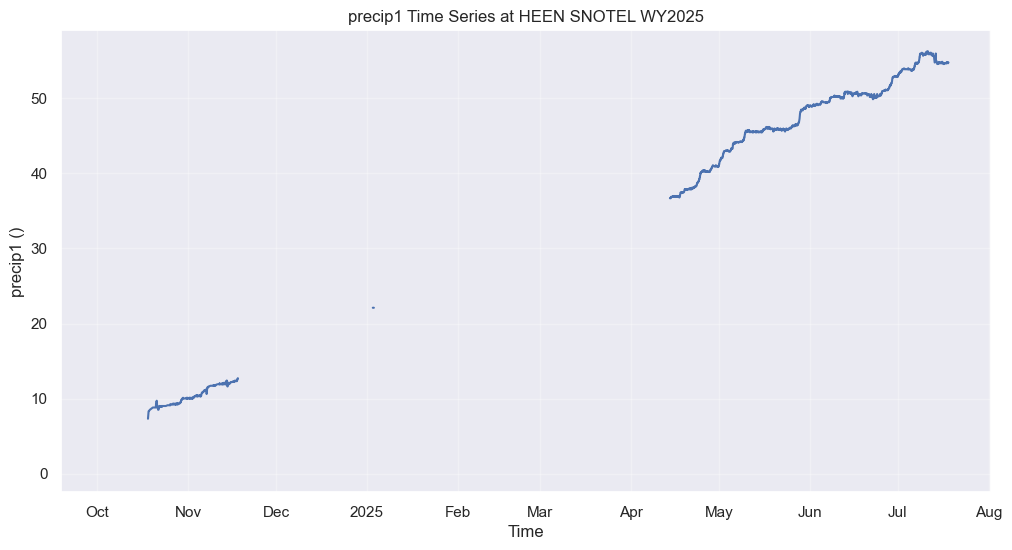

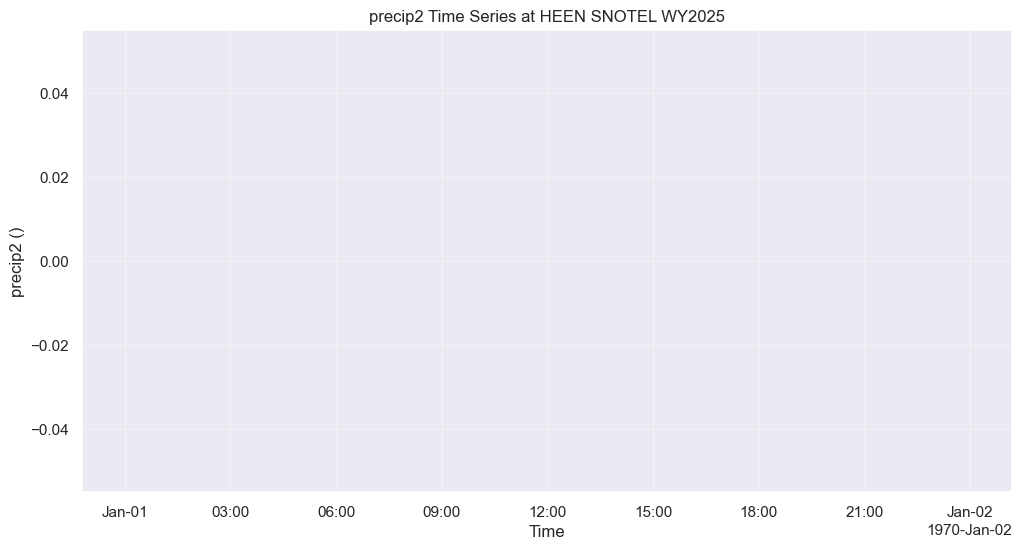

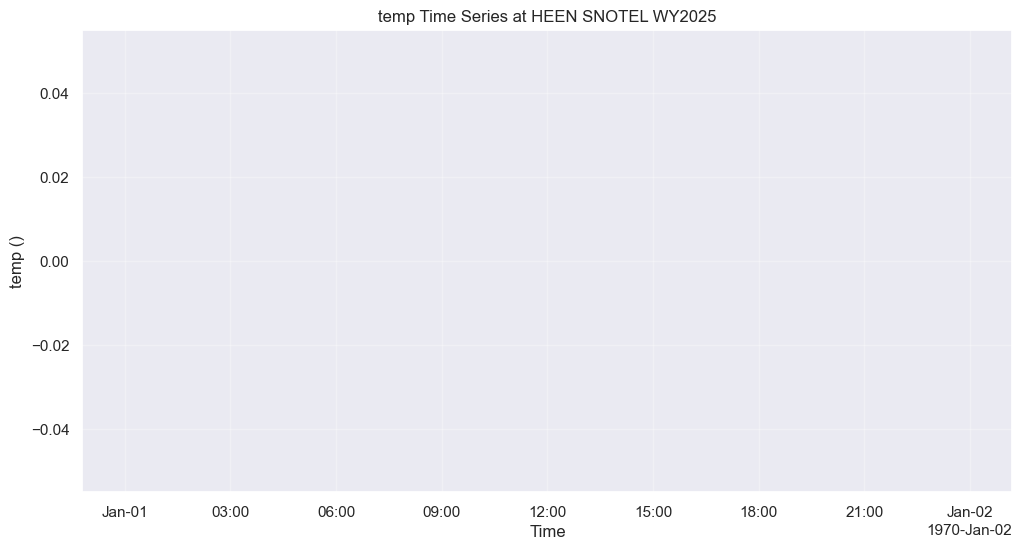

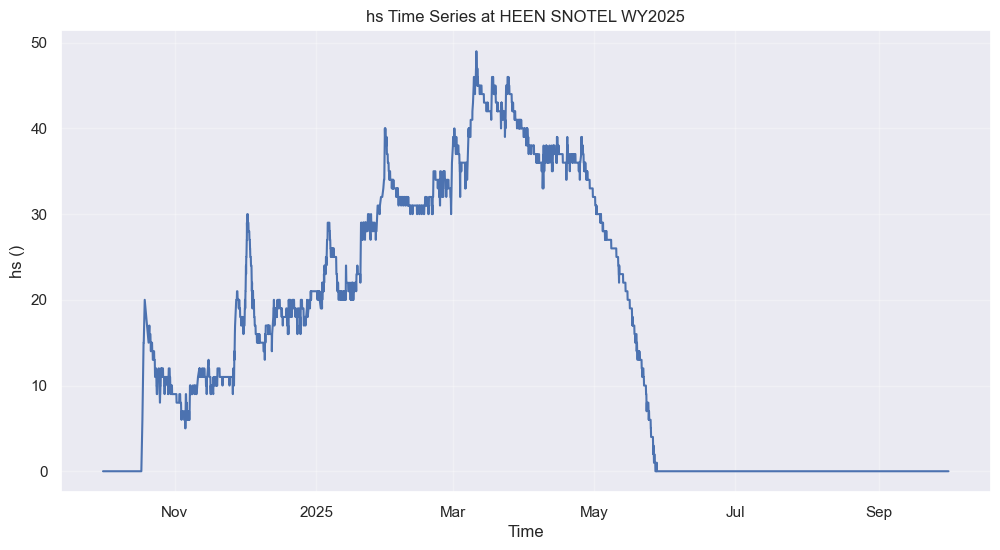

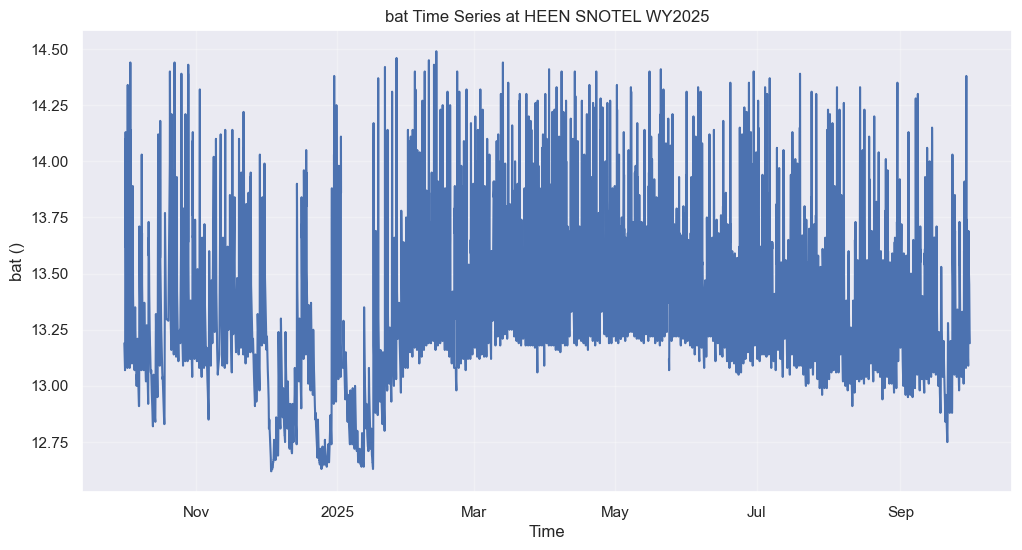

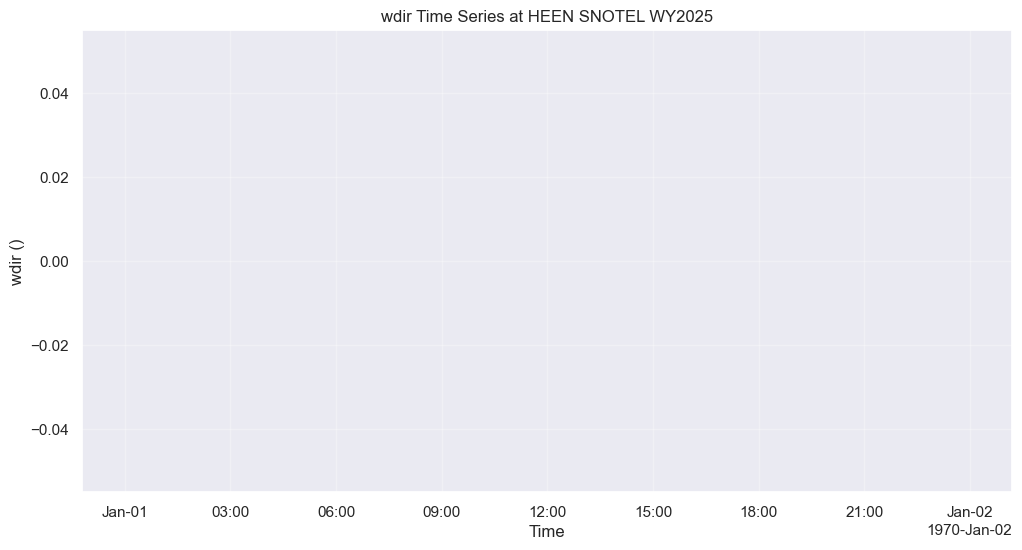

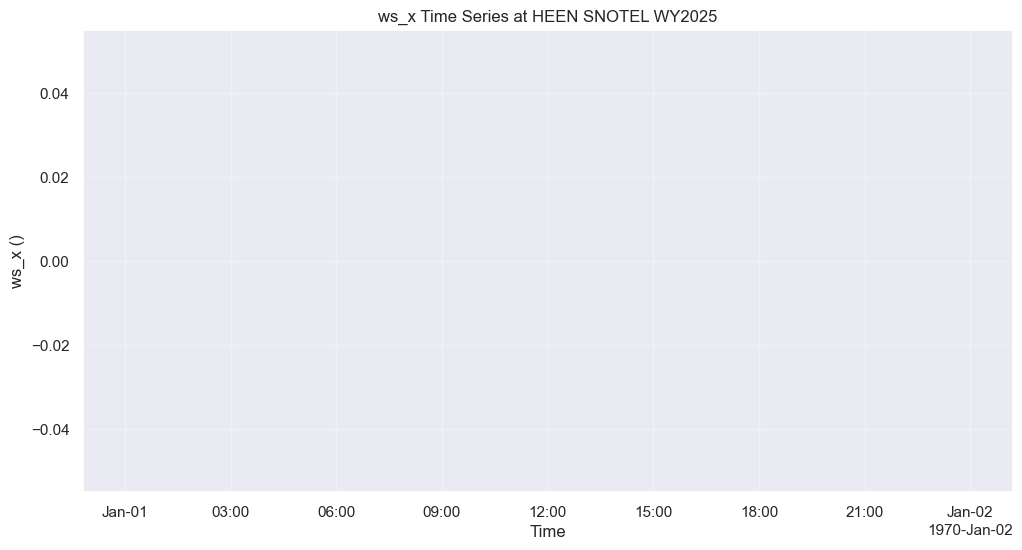

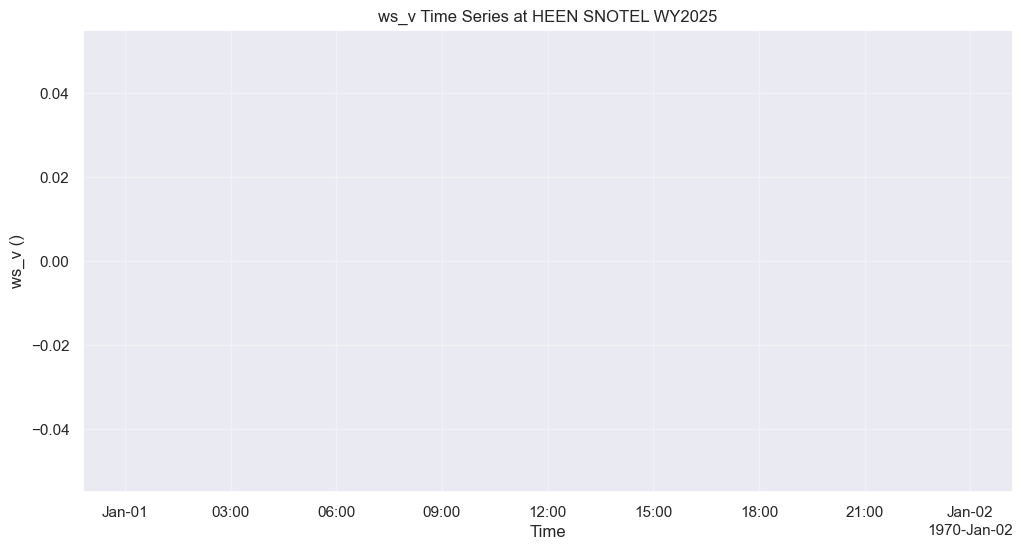

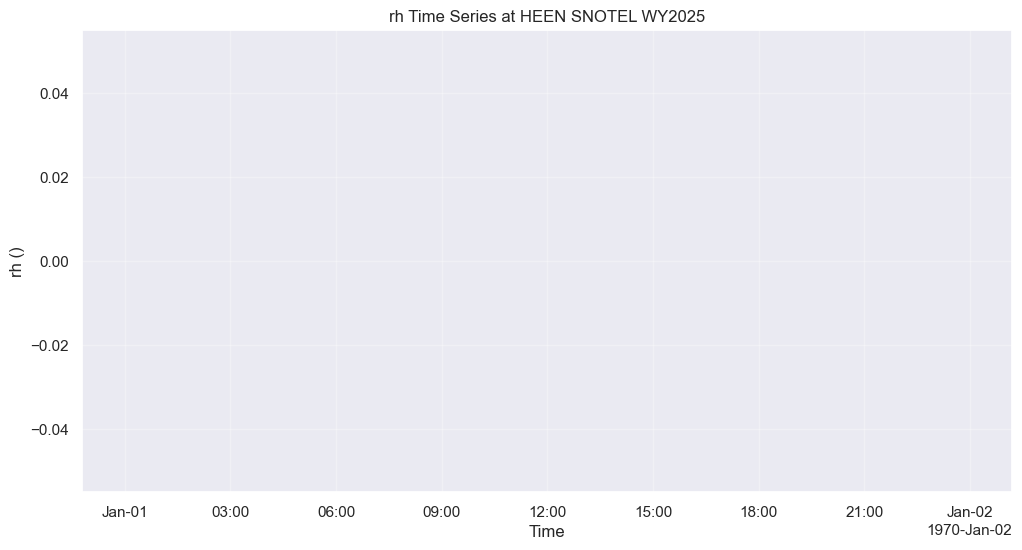

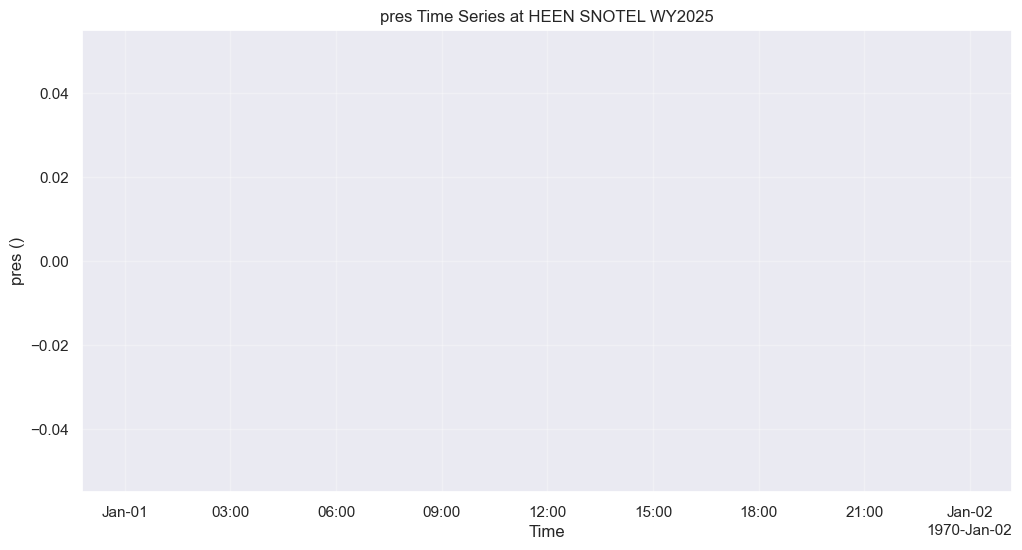

In [6]:
# light cleaning: remove all data < -90 
met_heen_WY2025_clean = met_heen_WY2025.where(met_heen_WY2025 > -90)

# plot all the variables to see what we have and how they look
for var in met_heen_WY2025_clean.data_vars:
    plt.figure()
    met_heen_WY2025_clean[var].plot()
    plt.title(f"{var} Time Series at HEEN SNOTEL WY2025")
    plt.xlabel("Time")
    plt.ylabel(f"{var} ({met_heen_WY2025_clean[var].attrs.get('units', '')})")
    plt.grid(True, alpha=0.3)
    plt.show()

In [7]:
met_heen_WY2025_clean.head()

<xarray.Dataset> Size: 520B
Dimensions:   (datetime: 5)
Coordinates:
  * datetime  (datetime) datetime64[ns] 40B 2024-10-01 ... 2024-10-01T04:00:00
Data variables:
    site_id   (datetime) float64 40B 1.27e+03 1.27e+03 ... 1.27e+03 1.27e+03
    swe       (datetime) float64 40B nan nan nan nan nan
    precip1   (datetime) float64 40B nan nan nan nan nan
    precip2   (datetime) float64 40B nan nan nan nan nan
    temp      (datetime) float64 40B nan nan nan nan nan
    hs        (datetime) float64 40B 0.0 0.0 0.0 0.0 0.0
    bat       (datetime) float64 40B 13.19 13.17 13.15 13.13 13.12
    wdir      (datetime) float64 40B nan nan nan nan nan
    ws_x      (datetime) float64 40B nan nan nan nan nan
    ws_v      (datetime) float64 40B nan nan nan nan nan
    rh        (datetime) float64 40B nan nan nan nan nan
    pres      (datetime) float64 40B nan nan nan nan nan

In [8]:
# look at any attributes for the heen variables swe and hs 
print(met_heen_WY2025_clean['swe'])
print(met_heen_WY2025_clean['hs'])

<xarray.DataArray 'swe' (datetime: 7772)> Size: 62kB
array([nan, nan, nan, ..., nan, nan, nan], shape=(7772,))
Coordinates:
  * datetime  (datetime) datetime64[ns] 62kB 2024-10-01 ... 2025-09-30T23:00:00
<xarray.DataArray 'hs' (datetime: 7772)> Size: 62kB
array([0., 0., 0., ..., 0., 0., 0.], shape=(7772,))
Coordinates:
  * datetime  (datetime) datetime64[ns] 62kB 2024-10-01 ... 2025-09-30T23:00:00


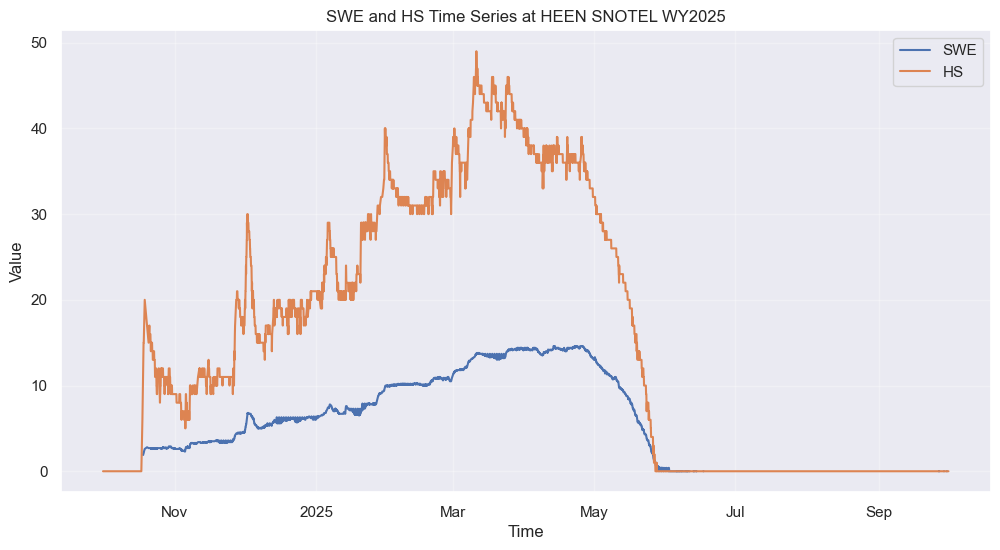

In [9]:
# plot swe and hs together to see how they look
plt.figure()
met_heen_WY2025_clean['swe'].plot(label='SWE')
met_heen_WY2025_clean['hs'].plot(label='HS')
plt.title("SWE and HS Time Series at HEEN SNOTEL WY2025")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

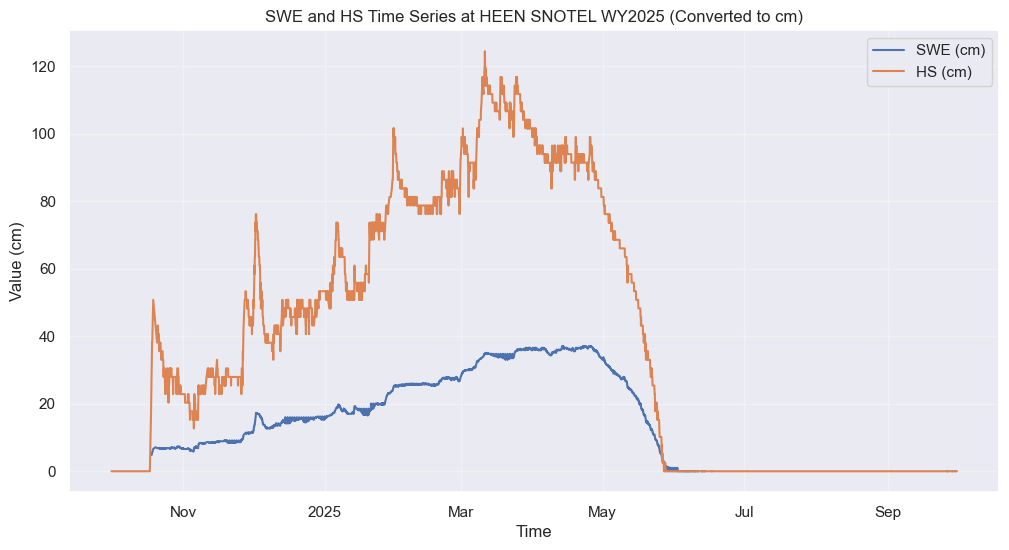

In [10]:
# it looks like inches, now covert to cm and replot to confirm
met_heen_WY2025_clean['swe_cm'] = met_heen_WY2025_clean['swe'] * 2.54
met_heen_WY2025_clean['hs_cm'] = met_heen_WY2025_clean['hs'] * 2.54

plt.figure()
met_heen_WY2025_clean['swe_cm'].plot(label='SWE (cm)')
met_heen_WY2025_clean['hs_cm'].plot(label='HS (cm)')
plt.title("SWE and HS Time Series at HEEN SNOTEL WY2025 (Converted to cm)")
plt.xlabel("Time")
plt.ylabel("Value (cm)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
met_heen_WY2025_clean

<xarray.Dataset> Size: 933kB
Dimensions:   (datetime: 7772)
Coordinates:
  * datetime  (datetime) datetime64[ns] 62kB 2024-10-01 ... 2025-09-30T23:00:00
Data variables: (12/14)
    site_id   (datetime) float64 62kB 1.27e+03 1.27e+03 ... 1.27e+03 1.27e+03
    swe       (datetime) float64 62kB nan nan nan nan nan ... nan nan nan nan
    precip1   (datetime) float64 62kB nan nan nan nan nan ... nan nan nan nan
    precip2   (datetime) float64 62kB nan nan nan nan nan ... nan nan nan nan
    temp      (datetime) float64 62kB nan nan nan nan nan ... nan nan nan nan
    hs        (datetime) float64 62kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    ...        ...
    ws_x      (datetime) float64 62kB nan nan nan nan nan ... nan nan nan nan
    ws_v      (datetime) float64 62kB nan nan nan nan nan ... nan nan nan nan
    rh        (datetime) float64 62kB nan nan nan nan nan ... nan nan nan nan
    pres      (datetime) float64 62kB nan nan nan nan nan ... nan nan nan nan
    swe_cm    (datetime) float64 62kB nan nan nan nan nan ... nan nan nan nan
    hs_cm     (datetime) float64 62kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [12]:
# save the cleaned dataset to a new netcdf file
# ORIGINAL file: file_heen = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/site1270_hourly_2016_2026.nc"
output_file = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/site1270_hourly_WY2025_clean.nc" # created in script 1_met_heen.ipynb
met_heen_WY2025_clean.to_netcdf(output_file)

## Look at which year at HEEN we can use to model...

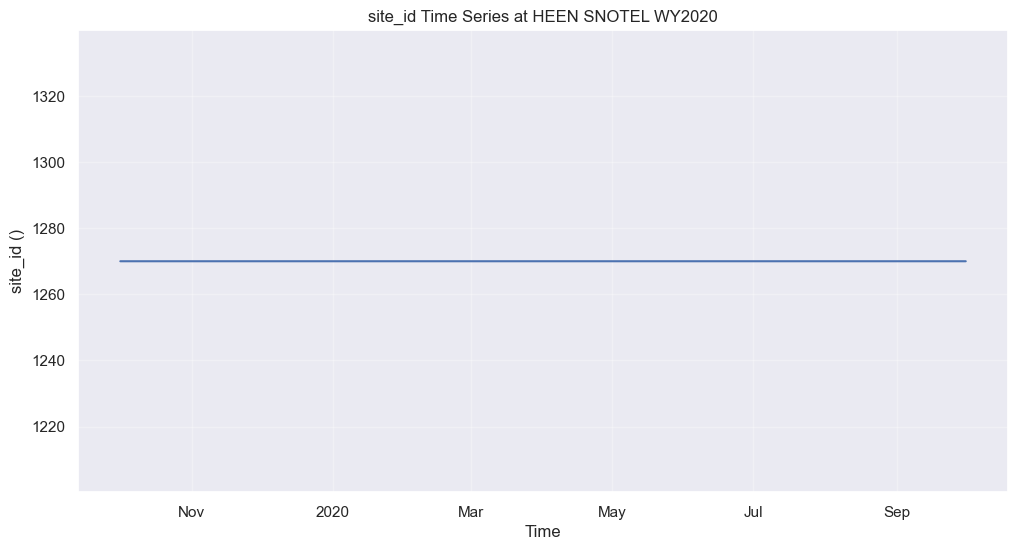

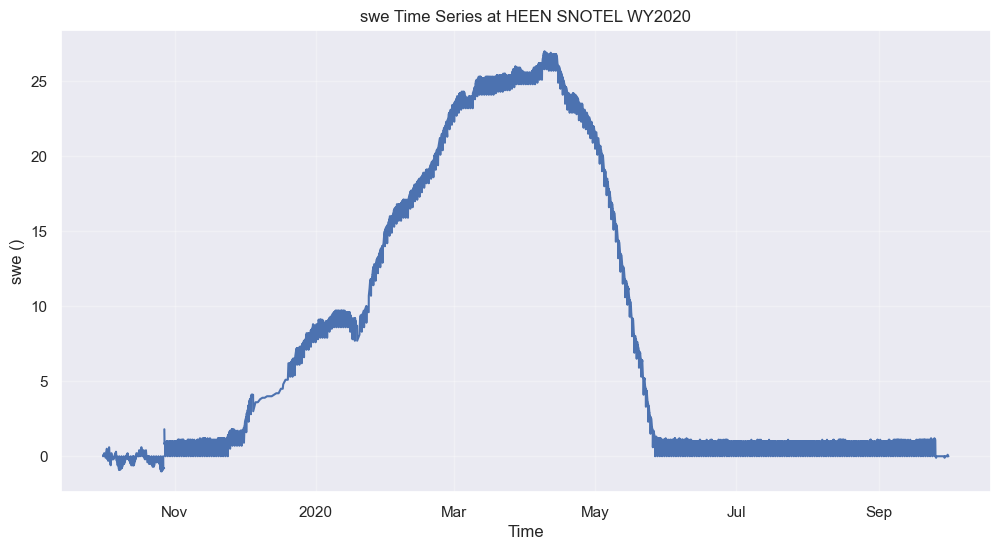

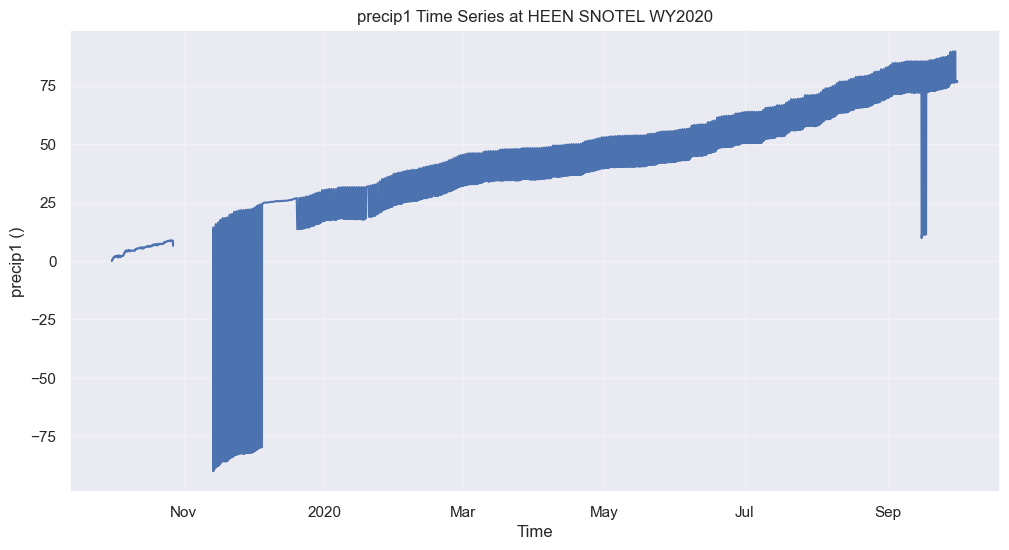

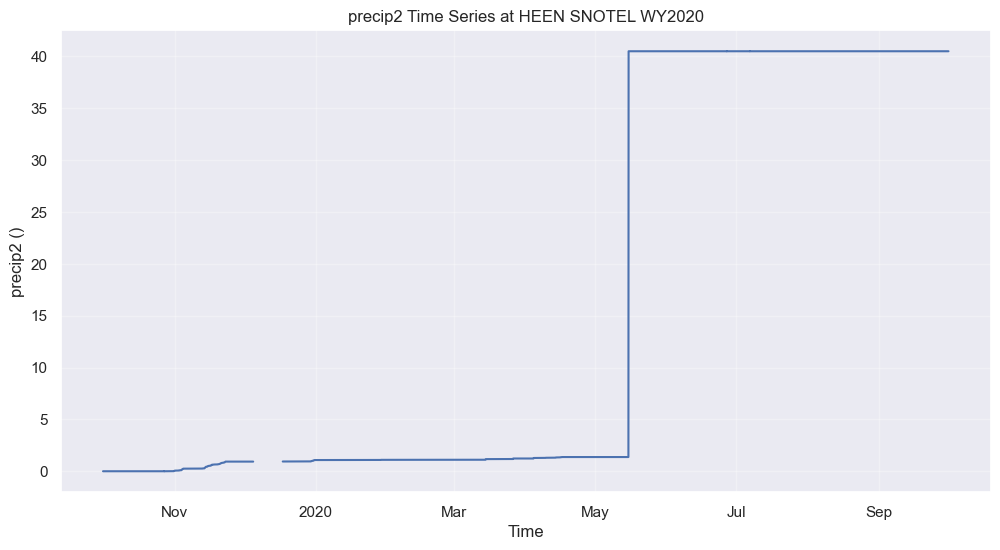

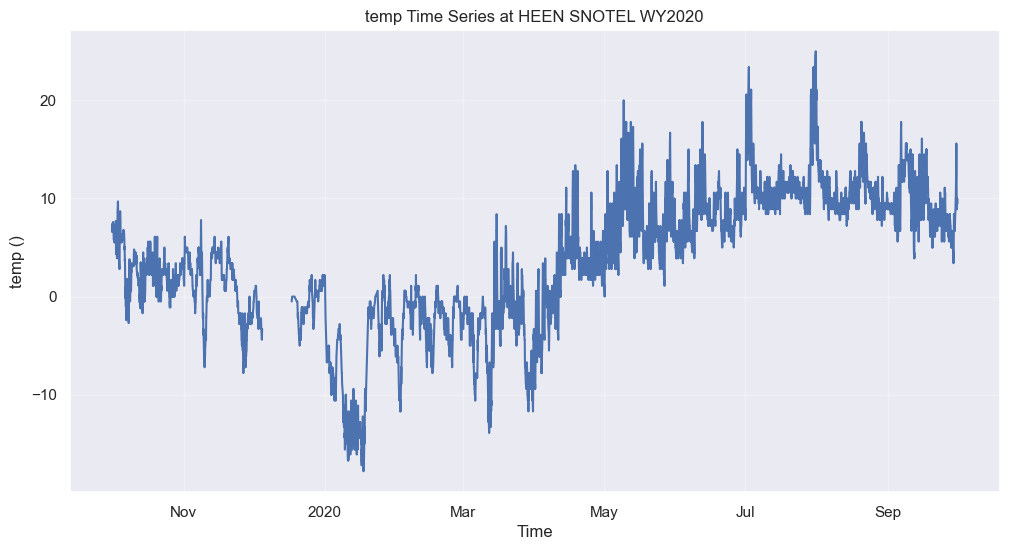

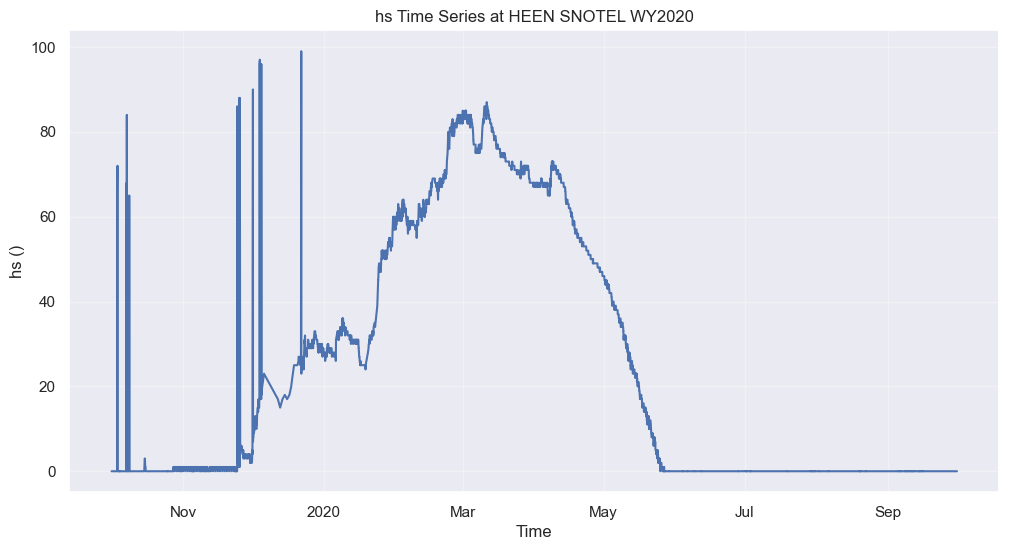

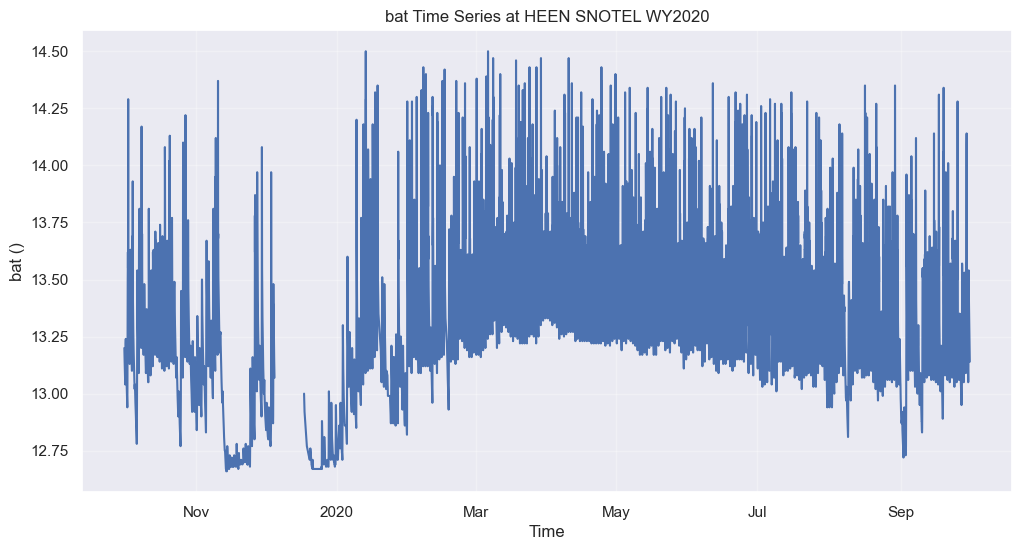

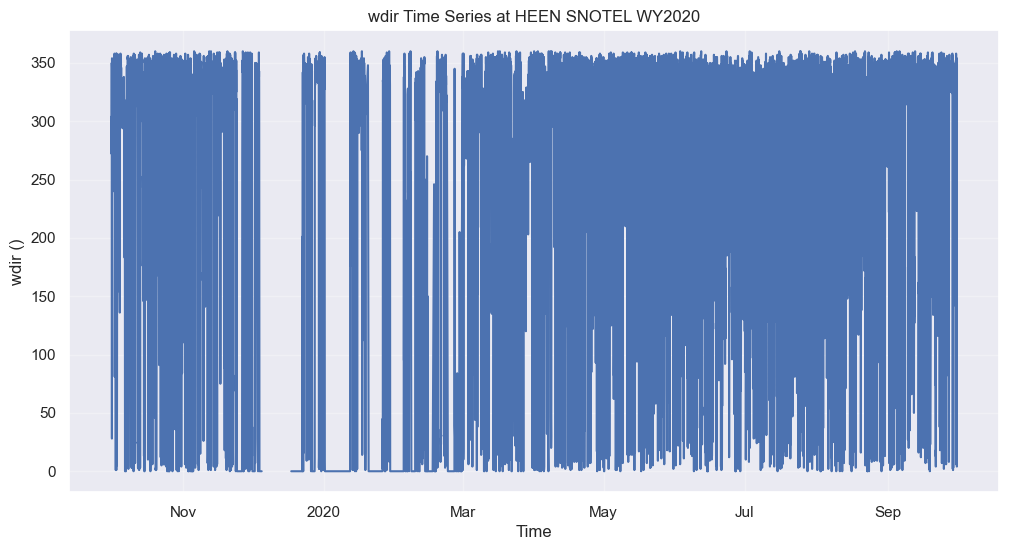

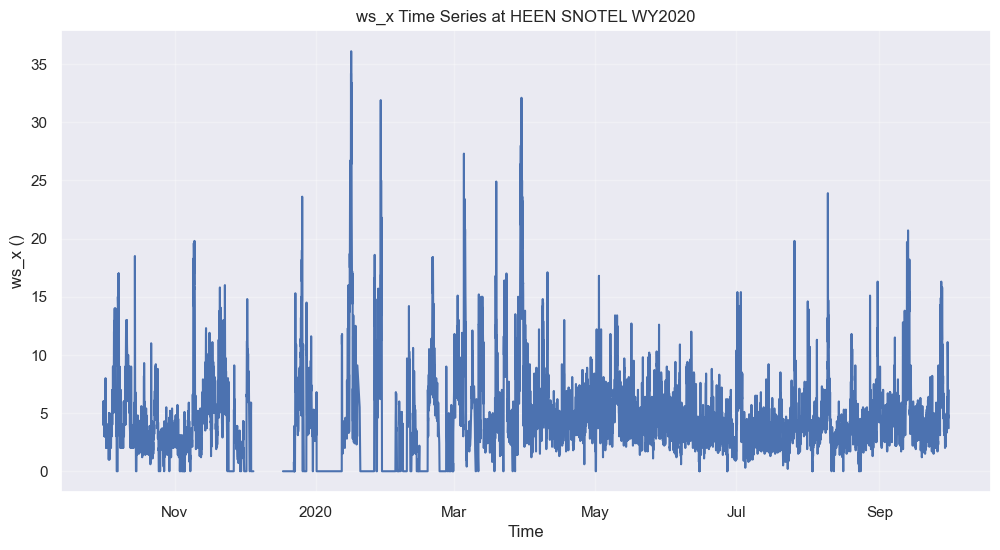

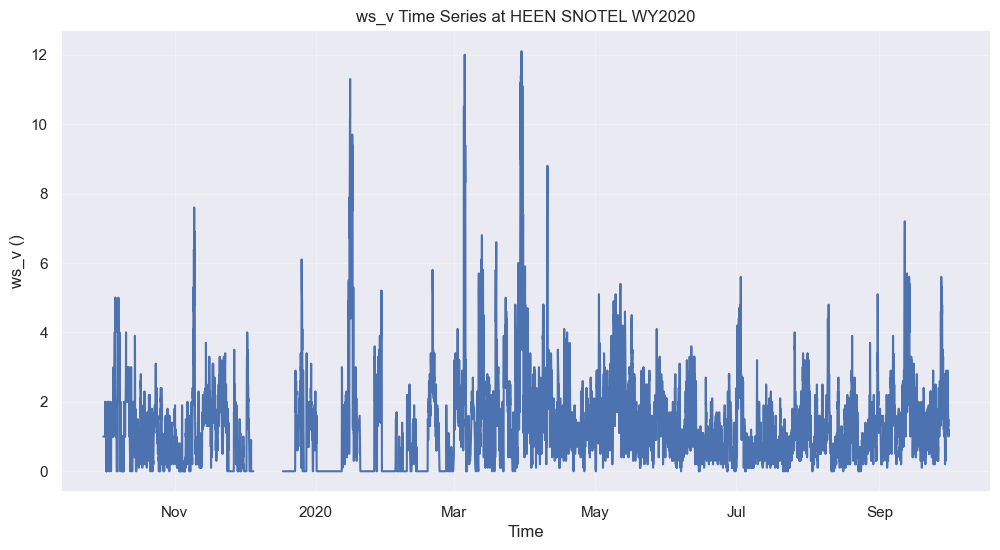

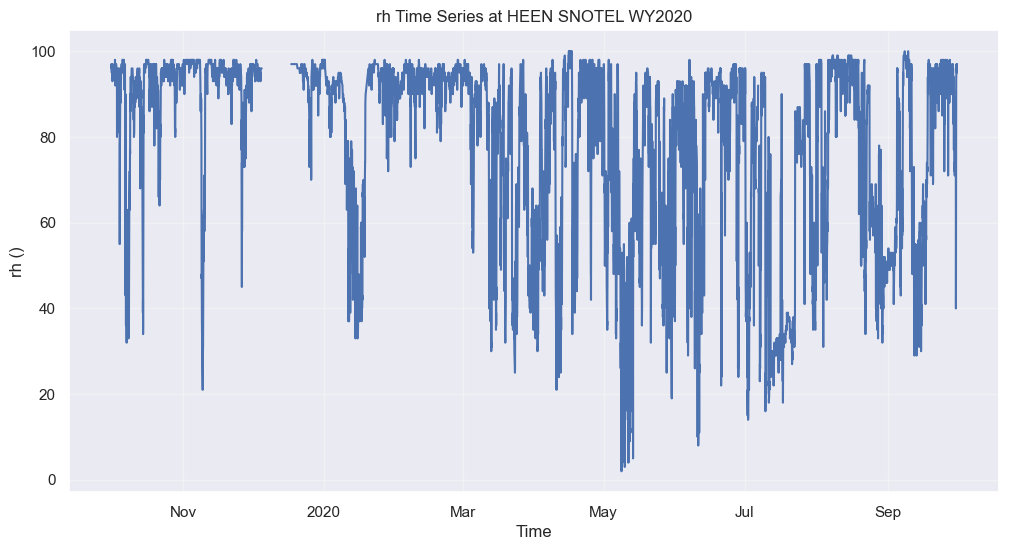

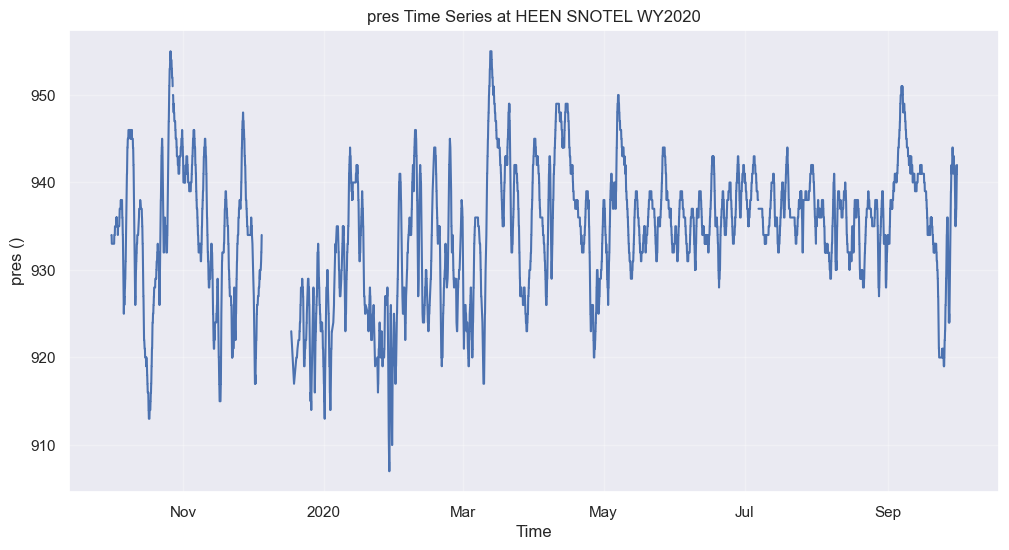

In [23]:
# Set the water year (WY) to analyze (e.g., 2020 for WY2020: Oct 1, 2019 - Sept 30, 2020)
wy_year = 2020

# Compute the start and end dates for the water year
start_date = f"{wy_year-1}-10-01"
end_date = f"{wy_year}-09-30"

# cut the datetime to match the water year
met_heen_WY = met_heen.sel(datetime=slice(start_date, end_date))

# light cleaning: remove all data < -90 
met_heen_WY_clean = met_heen_WY.where(met_heen_WY > -90)

# plot all the variables to see what we have and how they look
for var in met_heen_WY_clean.data_vars:
    plt.figure()
    met_heen_WY_clean[var].plot()
    plt.title(f"{var} Time Series at HEEN SNOTEL WY{wy_year}")
    plt.xlabel("Time")
    plt.ylabel(f"{var} ({met_heen_WY_clean[var].attrs.get('units', '')})")
    plt.grid(True, alpha=0.3)
    plt.show()

In [24]:
met_heen_WY_clean

<xarray.Dataset> Size: 825kB
Dimensions:   (datetime: 7930)
Coordinates:
  * datetime  (datetime) datetime64[ns] 63kB 2019-10-01 ... 2020-09-30T23:00:00
Data variables:
    site_id   (datetime) float64 63kB 1.27e+03 1.27e+03 ... 1.27e+03 1.27e+03
    swe       (datetime) float64 63kB 0.0 0.0 0.1 0.1 0.1 ... 0.0 0.0 0.0 0.0
    precip1   (datetime) float64 63kB 0.0 0.2 0.3 0.5 ... 76.8 76.7 76.8 76.8
    precip2   (datetime) float64 63kB 0.0 0.0 0.0 0.0 ... 40.5 40.5 40.5 40.5
    temp      (datetime) float64 63kB 6.6 6.9 7.1 7.4 7.2 ... 10.0 10.0 9.5 9.5
    hs        (datetime) float64 63kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    bat       (datetime) float64 63kB 13.2 13.17 13.16 ... 13.19 13.16 13.14
    wdir      (datetime) float64 63kB 304.0 272.0 350.0 ... 354.0 4.0 350.0
    ws_x      (datetime) float64 63kB 4.0 6.0 4.0 6.0 5.0 ... 7.0 4.6 4.8 3.7
    ws_v      (datetime) float64 63kB 1.0 1.0 1.0 1.0 1.0 ... 1.3 1.0 1.2 1.2
    rh        (datetime) float64 63kB 97.0 96.0 97.0 95.0 ... 96.0 95.0 97.0
    pres      (datetime) float64 63kB 934.0 934.0 933.0 ... 941.0 941.0 942.0

That was WY2021 above, so let's save it and move it to a different file to create the smet file

Also saved WY2020...

In [ ]:
# save the cleaned dataset to a new netcdf file
# ORIGINAL file: file_heen = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/site1270_hourly_2016_2026.nc"
# output_file = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/site1270_hourly_WY2021_clean.nc" # created in script 1_met_heen.ipynb
# output_file = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/site1270_hourly_WY2020_clean.nc" # created in script 1_met_heen.ipynb
# met_heen_WY_clean.to_netcdf(output_file)

### Load HRRR-AK at Heen

In [ ]:
# input_file = "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_f567_WY2025_utm_site_heen.nc"
input_file = "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_heen.nc"
ds = xr.open_dataset(input_file)
ds.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work
ds

<xarray.Dataset> Size: 2MB
Dimensions:       (time: 8760)
Coordinates:
  * time          (time) datetime64[ns] 70kB 2024-10-01T05:00:00 ... 2025-10-...
    valid_time    (time) datetime64[ns] 70kB ...
    step          (time) timedelta64[ns] 70kB ...
    y             float64 8B ...
    x             float64 8B ...
    spatial_ref   int64 8B 0
Data variables: (12/28)
    gust          (time) float64 70kB ...
    pressure      (time) float64 70kB ...
    orog          (time) float64 70kB ...
    temp_surface  (time) float64 70kB ...
    swe           (time) float64 70kB ...
    snowdepth     (time) float64 70kB ...
    ...            ...
    swrad         (time) float64 70kB ...
    lwrad         (time) float64 70kB ...
    suswrf        (time) float64 70kB ...
    sulwrf        (time) float64 70kB ...
    wind          (time) float64 70kB ...
    wind_dir      (time) float64 70kB ...
Attributes: (12/13)
    long_name:       Wind speed (gust)
    units:           m s**-1
    GRIB_shortName:  gust
    GRIB_name:       Wind speed (gust)
    GRIB_cfName:     unknown
    GRIB_cfVarName:  gust
    ...              ...
    typeOfLevel:     surface
    site_name:       heen
    original_lat:    58.69652
    original_lon:    -134.86448
    utm_x:           507854.334991801
    utm_y:           6506268.082489309

#### MeteoIO Variable Names 
| MeteoIO name | Meaning                      | Required?            | Expected units              |
| ------------ | ---------------------------- | -------------------- | --------------------------- |
| `TA`         | Air temperature              | yes                  | °K                          |
| `RH`         | Relative humidity            | yes                  | fraction (0-1)              |
| `VW`         | Wind speed                   | yes                  | m s⁻¹                       |
| `DW`         | Wind direction               | optional             | degrees (0–360, from North) |
| `ISWR`       | Incoming shortwave radiation | strongly recommended | W m⁻²                       |
| `ILWR`       | Incoming longwave radiation  | strongly recommended | W m⁻²                       |
| `PSUM`       | Precipitation (increment)    | yes                  | mm (per timestep)           |
| `P`          | Air pressure                 | optional             | Pa                          |


HRRR to MeteIO Variable Mapping 

In [15]:
# --- Unit expectations (SMET / MeteoIO) ---
# TA    : Kelvin
# RH    : fraction (0–1)
# VW    : m s-1
# DW    : degrees (meteorological)
# ISWR : W m-2
# ILWR : W m-2
# PSUM : mm per timestep
# P     : Pa